In [3]:
%%capture
!pip install scikit-learn

In [5]:
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

#Um projeto de Regressão Linear

#Pergunta:
  - Qual a quantidade de carros uma cidade americana tem em relação ao pib da mesma cidade.

In [7]:
df = pd.read_csv('/content/frota_carro_eletricos_eua.csv', on_bad_lines= 'skip')

In [8]:
df.head()

,VIN (1-10),County,City,State,Postal Code,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Legislative District,DOL Vehicle ID,Vehicle Location,Electric Utility,2020 GEOID
0,5YJ3E1EA5L,Yakima,Yakima,WA,98908.0,2020,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,266.0,14.0,102765120,POINT (-120.60272 46.59656),PACIFICORP,5.307700e+10
1,5YJ3E1EA9K,Thurston,Olympia,WA,98502.0,2019,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,220.0,22.0,326796641,POINT (-122.92018 47.04575),PUGET SOUND ENERGY INC,5.306701e+10
2,5YJSA1H22F,Kitsap,Kingston,WA,98346.0,2015,TESLA,MODEL S,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,208.0,23.0,166294418,POINT (-122.4977 47.79802),PUGET SOUND ENERGY INC,5.303509e+10
3,KM8K33AG7L,King,Seattle,WA,98107.0,2020,HYUNDAI,KONA,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,258.0,43.0,127090015,POINT (-122.38591 47.67597),CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),5.303300e+10
4,5YJ3E1EB1K,Yakima,Yakima,WA,98902.0,2019,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,220.0,14.0,272512824,POINT (-120.51904 46.59782),PACIFICORP,5.307700e+10


In [ ]:
# Wayoming

In [20]:
# Contando a quantidade de carros
contagem_carros = df.City.value_counts().reset_index().sort_values(by="count" ,ascending= False)

In [23]:
contagem_carros.head(280).describe()

,count
count,280.000000
mean,1042.167857
std,3193.827263
min,27.000000
25%,68.000000
50%,200.500000
75%,806.000000
max,44697.000000


In [16]:
df.sort_values?

In [13]:
pop_cities = pd.read_csv('/content/washington-cities-v2025.csv')

In [24]:
pop_cities

,state_rank_pop_2025,city,state,state_name,pop_2025,pop_base_2020,growth_2020_2025_abs,growth_2020_2025_pct,slug
0,1,Seattle,WA,Washington,784777,737103,47674,6.467753,seattle-wa
1,2,Spokane,WA,Washington,230783,228965,1818,0.794008,spokane-wa
2,3,Tacoma,WA,Washington,229816,219651,10165,4.627796,tacoma-wa
3,4,Vancouver,WA,Washington,199698,190884,8814,4.617464,vancouver-wa
4,5,Bellevue,WA,Washington,154193,151866,2327,1.532272,bellevue-wa
...,...,...,...,...,...,...,...,...,...
276,277,Kahlotus,WA,Washington,141,144,-3,-2.083333,kahlotus-wa
277,278,Farmington,WA,Washington,133,131,2,1.526718,farmington-wa
278,279,Waverly,WA,Washington,129,127,2,1.574803,waverly-wa
279,280,Lamont,WA,Washington,78,78,0,0.000000,lamont-wa


In [26]:
contagem_carros.tail()

,City,count
917,Chantilly,1
916,El Cajon,1
915,Brewer,1
914,Bowie,1
913,Juneau,1


In [32]:
contagem_carros = contagem_carros.set_index('City')

In [37]:
import numpy as np

In [38]:
indices = np.array([cidade for cidade in pop_cities['city'] if cidade in contagem_carros.index])

In [49]:
# Separando as cidades que serão utilizadas
cidades_alvo = contagem_carros.loc[indices].reset_index().sort_values(by= 'count', ascending= False)

In [44]:
df.loc[[0, 1, 2, 3, 4]]

,VIN (1-10),County,City,State,Postal Code,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Legislative District,DOL Vehicle ID,Vehicle Location,Electric Utility,2020 GEOID
0,5YJ3E1EA5L,Yakima,Yakima,WA,98908.0,2020,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,266.0,14.0,102765120,POINT (-120.60272 46.59656),PACIFICORP,5.307700e+10
1,5YJ3E1EA9K,Thurston,Olympia,WA,98502.0,2019,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,220.0,22.0,326796641,POINT (-122.92018 47.04575),PUGET SOUND ENERGY INC,5.306701e+10
2,5YJSA1H22F,Kitsap,Kingston,WA,98346.0,2015,TESLA,MODEL S,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,208.0,23.0,166294418,POINT (-122.4977 47.79802),PUGET SOUND ENERGY INC,5.303509e+10
3,KM8K33AG7L,King,Seattle,WA,98107.0,2020,HYUNDAI,KONA,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,258.0,43.0,127090015,POINT (-122.38591 47.67597),CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),5.303300e+10
4,5YJ3E1EB1K,Yakima,Yakima,WA,98902.0,2019,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,220.0,14.0,272512824,POINT (-120.51904 46.59782),PACIFICORP,5.307700e+10


In [50]:
cidades_alvo

,City,count
0,Seattle,44697
4,Bellevue,14151
3,Vancouver,10969
16,Redmond,9978
24,Bothell,9618
...,...,...
255,Wilson Creek,1
230,Albion,1
266,Kahlotus,1
268,Waverly,1


In [51]:
df_alvo = df.set_index('City').loc[indices]

In [52]:
df_alvo

,VIN (1-10),County,State,Postal Code,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Legislative District,DOL Vehicle ID,Vehicle Location,Electric Utility,2020 GEOID
City,,,,,,,,,,,,,,,
Seattle,KM8K33AG7L,King,WA,98107.0,2020,HYUNDAI,KONA,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,258.0,43.0,127090015,POINT (-122.38591 47.67597),CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),5.303300e+10
Seattle,KNDCE3LG9K,King,WA,98119.0,2019,KIA,NIRO,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,239.0,36.0,179618995,POINT (-122.36381 47.63046),CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),5.303301e+10
Seattle,5YJXCAE4XG,King,WA,98119.0,2016,TESLA,MODEL X,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,200.0,36.0,237753316,POINT (-122.36381 47.63046),CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),5.303301e+10
Seattle,5YJ3E1EBXJ,King,WA,98112.0,2018,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,215.0,43.0,2305915,POINT (-122.30207 47.64085),CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),5.303301e+10
Seattle,5YJSA1E21H,King,WA,98101.0,2017,TESLA,MODEL S,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,210.0,43.0,137098839,POINT (-122.34223 47.61085),CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),5.303301e+10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Kahlotus,5YJYGDEE8M,Franklin,WA,99335.0,2021,TESLA,MODEL Y,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0.0,9.0,254824762,POINT (-118.55453 46.64222),BONNEVILLE POWER ADMINISTRATION||BIG BEND ELEC...,5.302102e+10
Farmington,1G1RC6S56H,Whitman,WA,99128.0,2017,CHEVROLET,VOLT,Plug-in Hybrid Electric Vehicle (PHEV),Clean Alternative Fuel Vehicle Eligible,53.0,9.0,287947740,POINT (-117.04546 47.08917),AVISTA CORP,5.307500e+10
Farmington,1C4RJXN66R,Whitman,WA,99128.0,2024,JEEP,WRANGLER,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,21.0,9.0,270100449,POINT (-117.04546 47.08917),AVISTA CORP,5.307500e+10


In [53]:
df.columns

Index(['VIN (1-10)', 'County', 'City', 'State', 'Postal Code', 'Model Year',
       'Make', 'Model', 'Electric Vehicle Type',
       'Clean Alternative Fuel Vehicle (CAFV) Eligibility', 'Electric Range',
       'Legislative District', 'DOL Vehicle ID', 'Vehicle Location',
       'Electric Utility', '2020 GEOID'],
      dtype='object')

In [ ]:
# AGEMC

# ASK
# GET
# EXPLORER
# MODEL
# COMUNICATE

In [55]:
df['Model'].value_counts()

,count
Model,
MODEL Y,64984
MODEL 3,38980
LEAF,13368
MODEL S,7808
BOLT EV,7530
...,...
RCV,2
BENTAYGA,2
VALHALLA,1


In [59]:
df['Make'].value_counts()

,count
Make,
TESLA,120899
CHEVROLET,19964
FORD,15983
NISSAN,15947
KIA,14586
TOYOTA,13526
BMW,12152
HYUNDAI,11966
RIVIAN,9537


In [71]:
carros_vendidos_contagem = df['Model Year'].value_counts().reset_index().sort_values(by= 'Model Year')

In [74]:
carros_vendidos_contagem['Model Year'] = pd.to_datetime(carros_vendidos_contagem['Model Year'], format= '%Y')

In [75]:
carros_vendidos_contagem

,Model Year,count
20,1999-01-01,3
19,2000-01-01,7
22,2002-01-01,1
21,2003-01-01,1
18,2008-01-01,17
17,2010-01-01,20
15,2011-01-01,527
14,2012-01-01,1287
12,2013-01-01,3806
13,2014-01-01,3093


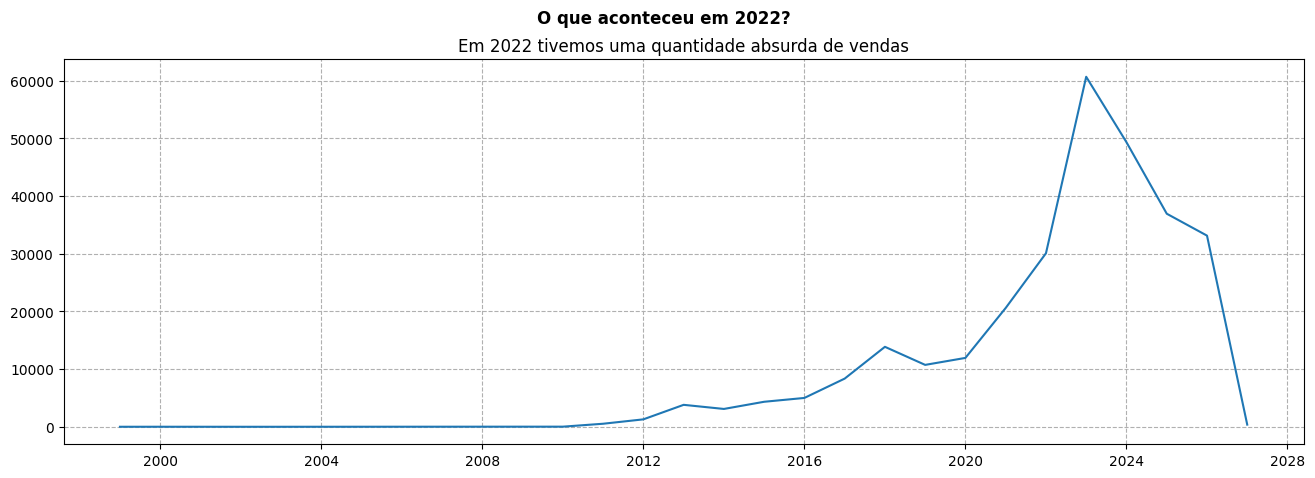

In [83]:
plt.figure(figsize= (16, 5))
plt.plot(carros_vendidos_contagem['Model Year'], carros_vendidos_contagem['count'])


plt.suptitle("O que aconteceu em 2022?",
             fontfamily= 'sans-serif',
             fontweight= 'bold')

plt.title("Em 2022 tivemos uma quantidade absurda de vendas")

plt.grid(True, linestyle= '--');